# Meteora DLMM Bin Atlas: connecting, fetching, normalizing, visualizing

Read-only research notebook for Meteora DLMM **bin-level liquidity**. No Solana node, no wallet, no transactions.

## Summary

| | |
|---|---|
| **Goal** | Build intuition for the DLMM bin lattice, then load one real pool snapshot and inspect how liquidity is distributed around the active bin. |
| **Unit of data** | One row per **price bin** — fixed price `P`, reserves `(x, y)`, liquidity `L`, and distance from the active bin. |
| **Data sources** | **Solana RPC** (`SOLANA_RPC_URL`) — JSON-RPC to a hosted node, same role as Infura/Alchemy on Ethereum; plus **Meteora datapi** for pool discovery and **`data/manual_pools.json`** fallback. See [RPC model](#rpc-model) below. |
| **Pipeline** | `discover:pools` → `fetch:pool` → `fetch:bins` → `normalize:bins` → CSV in `data/processed/` |
| **Outputs** | Raw JSON under `data/raw/`, normalized `bin_atlas_<pool>_<ts>.csv`, tables and plots in this notebook. |
| **Out of scope** | Swaps, LP deposits, wallets, trading, or live indexing — we only **read** chain state. |

## Notebook flow

1. **Setup** — env, RPC model
2. **Concepts** — `(P, L) ↔ (x, y)` coordinate embedding; swap book-walk; **how LPs refill shelves after trades**
3. **Fetch** — run TypeScript pipeline for one pool
4. **Explore** — load CSV, sanity checks, color-coded bin-structure table, liquidity plot

The conceptual sections use toy numbers; the fetch/explore sections use real on-chain data.

## Environment

In [21]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path
from urllib.parse import urlparse
from dotenv import load_dotenv

PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
PLOTS_DIR = PROJECT_ROOT / "plots"

load_dotenv(PROJECT_ROOT / ".env")


def latest_matching(directory: Path, pattern: str) -> Path:
    matches = sorted(directory.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No files matching {pattern} in {directory}")
    return matches[-1]


print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/echow/Desktop/meteora_bin_atlas


## RPC model

We connect through an RPC provider using `SOLANA_RPC_URL`. This is read-only. We never print the full URL (it may contain API keys).

In [22]:
rpc_url = os.getenv("SOLANA_RPC_URL", "")
rpc_host = urlparse(rpc_url).hostname or "(not set)"
cluster = os.getenv("SOLANA_CLUSTER", "mainnet-beta")

print(f"RPC host: {rpc_host}")
print(f"Cluster: {cluster}")

RPC host: api.mainnet-beta.solana.com
Cluster: mainnet-beta


## Coordinate embedding: (P, L) and the pullback to (x, y)

Each DLMM bin is a **fixed-price shelf** on a discrete ladder. Two coordinate layers describe the same liquidity:

1. **Price–liquidity space** `(P, L)` — each bin index `i` maps to a price `P(i)`; the pool reports a liquidity scalar `L` for that shelf.
2. **Reserve space** `(x, y)` — the actual token inventories stored on-chain in that bin.

Meteora's per-bin binding ([DLMM formulas](https://docs.meteora.ag/core-products/dlmm/formulas.md)) ties them together:

```text
L = P · x + y
```

Read `P` as the bin's fixed price (here: USDC per SOL), with `x` in SOL and `y` in USDC. `L` is the bin's liquidity measured in **Y terms** at that price.

**Pullback along the embedding:** given `(P, L)` on a shelf, feasible reserves lie on the line `y = L − P·x` in `(x, y)` space. DLMM placement picks a corner of that line:

- **Bid bins** (`distance < 0`): `x = 0`, so `L = y` — shelf is Y-only (USDC waiting if price falls).
- **Ask bins** (`distance > 0`): `y = 0`, so `L = P·x` — shelf is X-only (SOL waiting if price rises).
- **Active bin** (`distance = 0`): often a mix of both as price sits on the handoff.

The table and diagram below use **illustrative units** (same structure as the real bin atlas loaded later).

,distance_from_active,side,P (USDC/SOL),x (SOL),y (USDC),L = P·x + y (USDC),"pullback (x,y)"
0,-1,Bid shelf,149.63,0.00,1800000.0,1.800000e+06,x=0 → y=L
1,0,Active shelf,150.00,1.68,1837912.0,1.838164e+06,mix on line y = L − P·x
2,1,Ask shelf,150.38,28824.88,0.0,4.334685e+06,y=0 → x=L/P


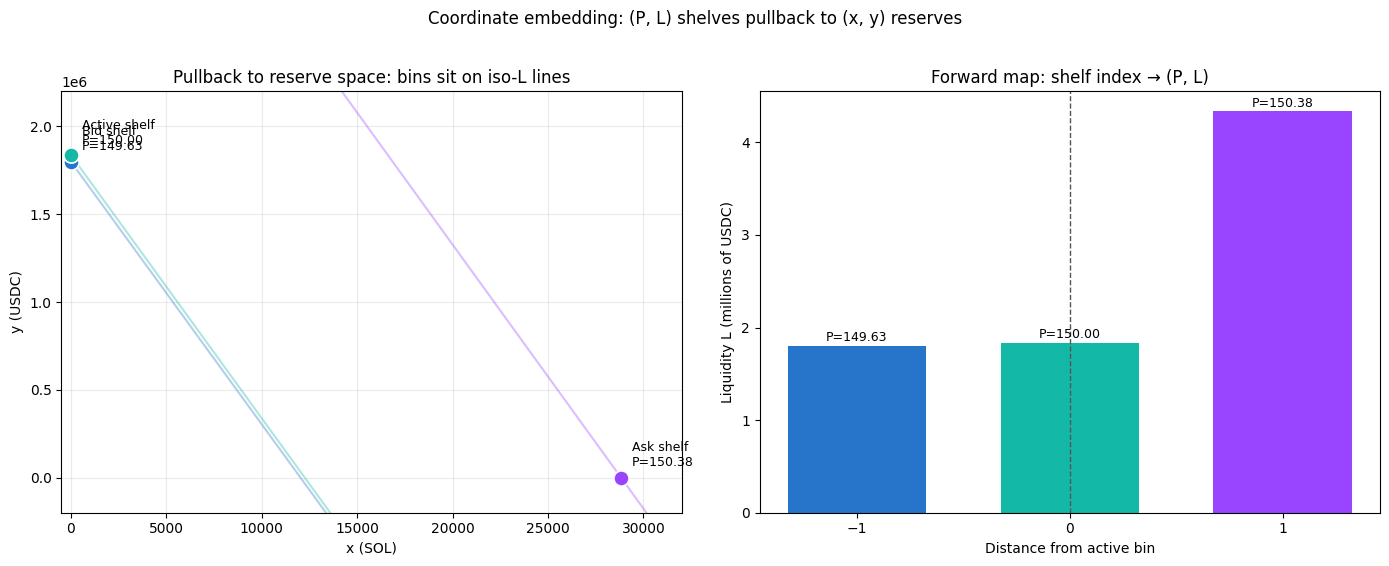

In [23]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Toy shelf prices around a notional active price (human units, not raw lamports)
P_ACTIVE = 150.0  # USDC per SOL
BIN_STEP_BPS = 25
step = BIN_STEP_BPS / 10_000
TOKEN_X, TOKEN_Y = "SOL", "USDC"

embedding_rows = [
    {
        "distance_from_active": -1,
        "side": "Bid shelf",
        "P (USDC/SOL)": round(P_ACTIVE / (1 + step), 2),
        "x (SOL)": 0.0,
        f"y ({TOKEN_Y})": 1_800_000.0,
    },
    {
        "distance_from_active": 0,
        "side": "Active shelf",
        "P (USDC/SOL)": P_ACTIVE,
        "x (SOL)": 1.68,
        f"y ({TOKEN_Y})": 1_837_912.0,
    },
    {
        "distance_from_active": 1,
        "side": "Ask shelf",
        "P (USDC/SOL)": round(P_ACTIVE * (1 + step), 2),
        "x (SOL)": 28_824.88,
        f"y ({TOKEN_Y})": 0.0,
    },
]

embedding_df = pd.DataFrame(embedding_rows)
embedding_df["L = P·x + y (USDC)"] = (
    embedding_df["P (USDC/SOL)"] * embedding_df["x (SOL)"] + embedding_df[f"y ({TOKEN_Y})"]
)
embedding_df["pullback (x,y)"] = [
    f"x=0  →  y=L",
    f"mix on line y = L − P·x",
    f"y=0  →  x=L/P",
]

display(embedding_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: reserve plane with iso-L lines and bin points
ax = axes[0]
x_line = np.linspace(0, 32_000, 200)
colors = {"bid": "#2775CA", "active": "#14B8A6", "ask": "#9945FF"}
labels = ["Bid shelf", "Active shelf", "Ask shelf"]
keys = ["bid", "active", "ask"]

for row, label, key in zip(embedding_rows, labels, keys):
    p = row["P (USDC/SOL)"]
    x = row["x (SOL)"]
    y = row[f"y ({TOKEN_Y})"]
    l_val = p * x + y
    ax.plot(x_line, l_val - p * x_line, color=colors[key], alpha=0.35, linewidth=1.5)
    ax.scatter([x], [y], s=120, color=colors[key], edgecolor="white", linewidth=1.2, zorder=3)
    ax.annotate(
        f"{label}\nP={p:.2f}",
        (x, y),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9,
    )

ax.set_xlim(-500, 32_000)
ax.set_ylim(-200_000, 2_200_000)
ax.set_xlabel(f"x ({TOKEN_X})")
ax.set_ylabel(f"y ({TOKEN_Y})")
ax.set_title("Pullback to reserve space: bins sit on iso-L lines")
ax.grid(True, alpha=0.25)

# Right: (distance, L) ladder view
ax2 = axes[1]
distances = embedding_df["distance_from_active"]
l_values = embedding_df["L = P·x + y (USDC)"]
bar_colors = [colors[k] for k in keys]
ax2.bar(distances, l_values / 1e6, width=0.65, color=bar_colors)
ax2.axvline(0, linestyle="--", color="#555555", linewidth=1)
ax2.set_xticks(distances)
ax2.set_xlabel("Distance from active bin")
ax2.set_ylabel("Liquidity L (millions of USDC)")
ax2.set_title("Forward map: shelf index → (P, L)")
for d, l_val, key in zip(distances, l_values, keys):
    ax2.text(d, l_val / 1e6 + 0.05, f"P={embedding_df.loc[embedding_df['distance_from_active']==d, 'P (USDC/SOL)'].iloc[0]:.2f}", ha="center", fontsize=9)

fig.suptitle("Coordinate embedding: (P, L) shelves pullback to (x, y) reserves", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

## How a swap walks the bin book

Inside one bin, trades execute at that bin's **fixed price** (zero price impact within the shelf). When the active shelf can no longer satisfy the trade, the pool **shifts the active bin** one step on the ladder — that is the discrete price jump.

Example: trader **buys SOL** (pool sends X, receives Y). The swap:

1. Consumes SOL from the **active bin** at `P_active`, crediting USDC into the same bin.
2. If SOL on that shelf runs out, the active bin moves **up** (`distance + 1`) into the next ask shelf.
3. Repeats until the order is filled or liquidity runs out.

Selling SOL is the mirror: consume USDC from active / bid shelves and walk **down** the ladder.

### After the swap: how does the pool get filled again?

**Swaps redistribute inventory; they do not mint new liquidity.** When traders buy SOL, ask-side bins lose `x` and gain `y`; shelves that were emptied stay thin until someone deposits again.

Refill comes from **LPs (liquidity providers)**, not from the swap engine:

| Mechanism | What happens |
|---|---|
| **Add liquidity** | An LP submits a deposit transaction targeting a **bin range** (and a shape: Spot, Curve, Bid-Ask). Tokens land on the chosen shelves — Y on bid bins, X on ask bins, mix near active. |
| **Fees** | Swap fees accrue to LPs in the bins that were traded through, incentivizing deposits near the active price. |
| **Reposition / remove** | LPs can widen, shift, or withdraw ranges as price moves — the lattice **deforms over time** as deposits and withdrawals land on-chain. |
| **No auto-refill** | The pool does not borrow or rebalance itself. Wrong-side or depleted **offering** depth (e.g. no SOL left to sell on ask shelves) stays that way until new `addLiquidity` or repositioning txs arrive. |

So the full loop is: **LPs seed shelves → traders swap (input token lands on bins, output token leaves) → active bin walks → LPs add depth or reposition.** This notebook snapshots on-chain inventory after deposits and trades; it does not simulate LP transactions.

The schematics below: (A) swap walk across shelves, (B) LP deposit restoring depleted ask depth.

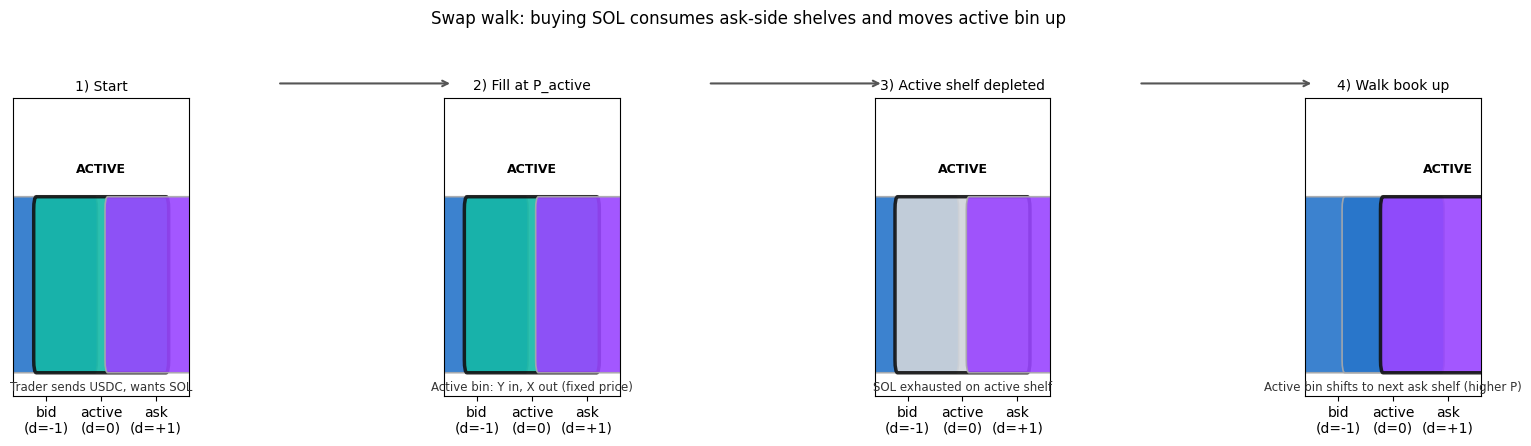

Swap walk (trader buys SOL):


,step,event,pool adjustment
0,1,Trader input,USDC (Y) arrives at active bin
1,2,Within-bin fill,SOL (X) leaves active bin at fixed P_active
2,3,Shelf empty,Active bin has no SOL left to sell
3,4,Book walk,active_bin_id += 1; next ask shelf becomes active
4,5,Repeat,Continue at higher price until order filled


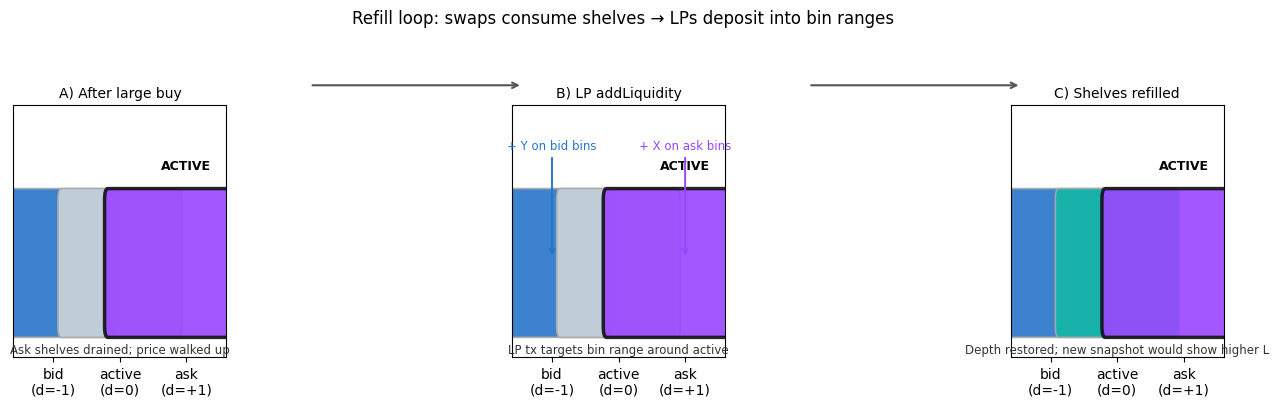


Refill loop (LP restores depth):


,step,event,who / what changes
0,1,Post-swap state,"Traded bins: offering token depleted, input to..."
1,2,LP deposit tx,"Wallet submits addLiquidity over [bin_min, bin..."
2,3,Token placement,"Y lands on bid shelves, X on ask shelves, mix ..."
3,4,On-chain update,bin.amountX / amountY / liquiditySupply increa...
4,5,Next snapshot,Our fetch pipeline reads the updated lattice (...


In [24]:
from matplotlib.patches import FancyBboxPatch

fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharey=True)
shelf_labels = ["bid\n(d=-1)", "active\n(d=0)", "ask\n(d=+1)"]
x_positions = [0, 1, 2]


def draw_shelves(ax, title, active_idx, fills, note):
    ax.set_xlim(-0.6, 2.6)
    ax.set_ylim(0, 1.15)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(shelf_labels)
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)

    for i, (x, fill) in enumerate(zip(x_positions, fills)):
        edge = "#111111" if i == active_idx else "#AAAAAA"
        width = 2.4 if i == active_idx else 1.8
        rect = FancyBboxPatch(
            (x - width / 2, 0.12),
            width,
            0.62,
            boxstyle="round,pad=0.03,rounding_size=0.05",
            linewidth=2.5 if i == active_idx else 1.2,
            edgecolor=edge,
            facecolor=fill,
            alpha=0.9,
        )
        ax.add_patch(rect)
        if i == active_idx:
            ax.text(x, 0.86, "ACTIVE", ha="center", fontsize=9, fontweight="bold")

    ax.text(1.0, 0.02, note, ha="center", fontsize=8.5, color="#333333")


draw_shelves(
    axes[0],
    "1) Start",
    active_idx=1,
    fills=["#2775CA55", "#14B8A6", "#9945FF55"],
    note="Trader sends USDC, wants SOL",
)
draw_shelves(
    axes[1],
    "2) Fill at P_active",
    active_idx=1,
    fills=["#2775CA55", "#14B8A699", "#9945FF55"],
    note="Active bin: Y in, X out (fixed price)",
)
draw_shelves(
    axes[2],
    "3) Active shelf depleted",
    active_idx=1,
    fills=["#2775CA55", "#D1D5DB", "#9945FF55"],
    note="SOL exhausted on active shelf",
)
draw_shelves(
    axes[3],
    "4) Walk book up",
    active_idx=2,
    fills=["#2775CA55", "#2775CA33", "#9945FF"],
    note="Active bin shifts to next ask shelf (higher P)",
)

for ax in axes[1:4]:
    ax.annotate(
        "",
        xy=(0.05, 1.05),
        xytext=(-0.95, 1.05),
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", color="#555555", lw=1.5),
    )

fig.suptitle("Swap walk: buying SOL consumes ask-side shelves and moves active bin up", y=1.05, fontsize=12)
fig.tight_layout()
plt.show()

swap_steps = pd.DataFrame(
    [
        ["1", "Trader input", "USDC (Y) arrives at active bin"],
        ["2", "Within-bin fill", "SOL (X) leaves active bin at fixed P_active"],
        ["3", "Shelf empty", "Active bin has no SOL left to sell"],
        ["4", "Book walk", "active_bin_id += 1; next ask shelf becomes active"],
        ["5", "Repeat", "Continue at higher price until order filled"],
    ],
    columns=["step", "event", "pool adjustment"],
)
print("Swap walk (trader buys SOL):")
display(swap_steps)

# --- Refill schematic: LPs restore depleted shelves ---
fig2, axes2 = plt.subplots(1, 3, figsize=(12.5, 3.8), sharey=True)

draw_shelves(
    axes2[0],
    "A) After large buy",
    active_idx=2,
    fills=["#2775CA55", "#D1D5DB", "#9945FF33"],
    note="Ask shelves drained; price walked up",
)
draw_shelves(
    axes2[1],
    "B) LP addLiquidity",
    active_idx=2,
    fills=["#2775CA55", "#D1D5DB", "#9945FF33"],
    note="LP tx targets bin range around active",
)
# Overlay deposit arrows on middle panel
axes2[1].annotate(
    "+ X on ask bins",
    xy=(2, 0.45),
    xytext=(2, 0.95),
    ha="center",
    fontsize=8.5,
    color="#9945FF",
    arrowprops=dict(arrowstyle="->", color="#9945FF", lw=1.4),
)
axes2[1].annotate(
    "+ Y on bid bins",
    xy=(0, 0.45),
    xytext=(0, 0.95),
    ha="center",
    fontsize=8.5,
    color="#2775CA",
    arrowprops=dict(arrowstyle="->", color="#2775CA", lw=1.4),
)
draw_shelves(
    axes2[2],
    "C) Shelves refilled",
    active_idx=2,
    fills=["#2775CA", "#14B8A6", "#9945FF"],
    note="Depth restored; new snapshot would show higher L",
)

for ax in axes2[1:3]:
    ax.annotate(
        "",
        xy=(0.05, 1.08),
        xytext=(-0.95, 1.08),
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", color="#555555", lw=1.5),
    )

fig2.suptitle("Refill loop: swaps consume shelves → LPs deposit into bin ranges", y=1.06, fontsize=12)
fig2.tight_layout()
plt.show()

refill_steps = pd.DataFrame(
    [
        ["1", "Post-swap state", "Traded bins: offering token depleted, input token accumulated (e.g. Y on ex-ask shelf)"],
        ["2", "LP deposit tx", "Wallet submits addLiquidity over [bin_min, bin_max] with chosen shape"],
        ["3", "Token placement", "Y lands on bid shelves, X on ask shelves, mix near active (per DLMM rules)"],
        ["4", "On-chain update", "bin.amountX / amountY / liquiditySupply increase in those bins"],
        ["5", "Next snapshot", "Our fetch pipeline reads the updated lattice (what this repo measures)"],
    ],
    columns=["step", "event", "who / what changes"],
)
print("\nRefill loop (LP restores depth):")
display(refill_steps)

## Fetch pool candidates

Run the TypeScript discovery script, then load the processed CSV.

In [25]:
!cd {PROJECT_ROOT} && npm run discover:pools


> meteora-bin-atlas@0.1.0 discover:pools
> tsx src/scripts/step1_discover_pools.ts

Discovery method: meteora_api
Candidate pools: 10
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/pools_2026-06-07T06-05-50-940Z.json
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/pool_candidates.csv
Warnings:
- Legacy Meteora API https://dlmm-api.meteora.ag/pair/all returned HTTP 404; using https://dlmm.datapi.meteora.ag/pools instead.
Pool discovery complete.
⠙

In [26]:
pool_candidates_path = DATA_PROCESSED / "pool_candidates.csv"
pool_candidates = pd.read_csv(pool_candidates_path)
pool_candidates.head()

,pool_address,token_x_mint,token_y_mint,bin_step,active_bin_id,raw_name_or_symbol_if_available,source,fetched_at_utc
0,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,So11111111111111111111111111111111111111112,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,4,-6872,SOL-USDC,meteora_api,2026-06-07T06:05:50.941Z
1,9p3aRWnbu5vAmHXvsToMGfwmbkTJSwGr5G5xxSxmkB8N,CWZ6BsdnjkDVTGkmL6bGbJXXig6ceef12KvyGQW14cMt,Es9vMFrzaCERmJfrF4H2FYD4KCoNkY11McCe8BenwNYB,80,-489,ANTFUN-USDT,meteora_api,2026-06-07T06:05:50.941Z
2,ANCx141SujgVdbKz9NTEH8F38qWsnyyXsVju64aU3qLB,98sMhvDwXj1RQi5c5Mndm3vPe9cBqPrbLaufMXFNMh5g,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,20,-1413,HYPE-USDC,meteora_api,2026-06-07T06:05:50.941Z
3,7ubS3GccjhQY99AYNKXjNJqnXjaokEdfdV915xnCb96r,cbbtcf3aa214zXHbiAZQwf4122FBYbraNdFqgw4iMij,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,4,16063,cbBTC-USDC,meteora_api,2026-06-07T06:05:50.941Z
4,HcCbiQqc55uHtP2MJu7BYdVPi9s4j45R4zXcwRmJgCXX,So11111111111111111111111111111111111111112,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,5,-5497,SOL-USDC,meteora_api,2026-06-07T06:05:50.941Z


## Choose one pool

Use the first discovered candidate, or set `POOL_ADDRESS` manually.

In [27]:
POOL_ADDRESS = pool_candidates.iloc[0]["pool_address"]
# POOL_ADDRESS = "5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6"

selected = pool_candidates[pool_candidates["pool_address"] == POOL_ADDRESS].iloc[0]
print(f"Pool: {POOL_ADDRESS}")
print(f"Label: {selected.get('raw_name_or_symbol_if_available', '')}")
print(f"Bin step: {selected.get('bin_step', '')}")

Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Label: SOL-USDC
Bin step: 4


## Fetch pool snapshot

In [28]:
!cd {PROJECT_ROOT} && npm run fetch:pool -- --pool {POOL_ADDRESS}


> meteora-bin-atlas@0.1.0 fetch:pool
> tsx src/scripts/step2_fetch_pool_snapshot.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Active bin ID: -6872
Active bin price: 64.039808155334235565
Bin step: 4 bps
Token X mint: So11111111111111111111111111111111111111112
Token Y mint: EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/pool_snapshot_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-05-54-444Z.json
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/pool_snapshot_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-05-54-444Z.json
Pool snapshot complete.
⠙

## Fetch bin arrays

In [29]:
!cd {PROJECT_ROOT} && npm run fetch:bins -- --pool {POOL_ADDRESS}


> meteora-bin-atlas@0.1.0 fetch:bins
> tsx src/scripts/step3_fetch_bin_arrays.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Server responded with 429 Too Many Requests.  Retrying after 500ms delay...
Server responded with 429 Too Many Requests.  Retrying after 1000ms delay...
Server responded with 429 Too Many Requests.  Retrying after 2000ms delay...
Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Method: getBinArrays
Bin arrays fetched: 195
Active bin ID: -6872
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/bin_arrays_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-05-55-586Z.json
Bin arrays fetch complete.
⠙

## Normalize bin atlas

In [30]:
!cd {PROJECT_ROOT} && npm run normalize:bins -- --pool {POOL_ADDRESS}


> meteora-bin-atlas@0.1.0 normalize:bins
> tsx src/scripts/step4_normalize_bin_atlas.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Input: /Users/echow/Desktop/meteora_bin_atlas/data/raw/bin_arrays_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-05-55-586Z.json
Method: getBinArrays
Bins normalized: 13650
Active bin rows: 1
Bins with non-zero liquidity: 4978
Active bin ID: -6872
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/bin_atlas_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-05-55-586Z.csv
Bin atlas normalization complete.
⠙

## Load bin atlas

In [31]:
latest_bin_atlas_path = latest_matching(
    DATA_PROCESSED, f"bin_atlas_{POOL_ADDRESS}_*.csv"
)
df = pd.read_csv(latest_bin_atlas_path)
print(f"Loaded: {latest_bin_atlas_path.name}")
df.head()

Loaded: bin_atlas_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-05-55-586Z.csv


,pool_address,fetched_at_utc,bin_array_index,bin_id,distance_from_active,price,price_per_token,liquidity,x_amount,y_amount,composition_y,is_active_bin,raw_bin_array_pubkey,raw_fields_json
0,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T06:05:55.586Z,-456,-31920,-25048,52717705093411,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52717705..."
1,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T06:05:55.586Z,-456,-31919,-25047,52738792175449,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52738792..."
2,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T06:05:55.586Z,-456,-31918,-25046,52759887692319,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52759887..."
3,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T06:05:55.586Z,-456,-31917,-25045,52780991647396,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52780991..."
4,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T06:05:55.586Z,-456,-31916,-25044,52802104044055,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52802104..."


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13650 entries, 0 to 13649
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pool_address          13650 non-null  str    
 1   fetched_at_utc        13650 non-null  str    
 2   bin_array_index       13650 non-null  int64  
 3   bin_id                13650 non-null  int64  
 4   distance_from_active  13650 non-null  int64  
 5   price                 13650 non-null  object 
 6   price_per_token       0 non-null      float64
 7   liquidity             13650 non-null  object 
 8   x_amount              13650 non-null  int64  
 9   y_amount              13650 non-null  int64  
 10  composition_y         4978 non-null   float64
 11  is_active_bin         13650 non-null  bool   
 12  raw_bin_array_pubkey  13650 non-null  str    
 13  raw_fields_json       13650 non-null  str    
dtypes: bool(1), float64(2), int64(5), object(2), str(4)
memory usage: 8.3+ MB


## Basic sanity checks

In [33]:
print("bin_id range:", df["bin_id"].min(), df["bin_id"].max())
print(
    "distance_from_active range:",
    df["distance_from_active"].min(),
    df["distance_from_active"].max(),
)
print("active bin rows:", df["is_active_bin"].astype(str).str.lower().eq("true").sum())

# Zoom window for plots (bins on each side of active)
ZOOM_BINS = 30

neighborhood_df = (
    df[df["distance_from_active"].between(-ZOOM_BINS, ZOOM_BINS)]
    .sort_values("bin_id")
    .copy()
)
neighborhood_df["liquidity"] = pd.to_numeric(neighborhood_df["liquidity"], errors="coerce").fillna(0)
neighborhood_df["x_amount"] = pd.to_numeric(neighborhood_df["x_amount"], errors="coerce").fillna(0)
neighborhood_df["y_amount"] = pd.to_numeric(neighborhood_df["y_amount"], errors="coerce").fillna(0)

print(f"\nNeighborhood rows (±{ZOOM_BINS} bins):", len(neighborhood_df))

bin_id range: -31920 30379
distance_from_active range: -25048 37251
active bin rows: 1

Neighborhood rows (±30 bins): 61


## DLMM side structure (why X and Y split around the active bin)

In a DLMM pool, liquidity is **not** symmetric around the active bin:

- **Bins below** the active bin (`distance_from_active < 0`) hold **token Y** (here: USDC). These are the bid side — liquidity waiting if price moves down.
- **Bins above** the active bin (`distance_from_active > 0`) hold **token X** (here: SOL). These are the ask side — liquidity waiting if price moves up.
- The **active bin** is the handoff: it typically holds a small mix of both as price sits on the boundary.

So it is normal to see **no Y on the ask side** and **no X on the bid side**. The data is not missing; that is how the lattice is laid out.

The **table below** lists every bin in the zoom window (±`ZOOM_BINS` around active) with side, what is stocked, and each bin's role. Rows are **color-coded by token**: blue = Y (USDC), purple = X (SOL), teal = both at the active bin. The **liquidity plot after that** uses the same colors.

In [34]:
POOL_LABEL = selected.get("raw_name_or_symbol_if_available", POOL_ADDRESS)
TOKEN_X = "SOL" if "SOL" in str(POOL_LABEL).split("-")[0] else "token X"
TOKEN_Y = str(POOL_LABEL).split("-")[-1] if "-" in str(POOL_LABEL) else "token Y"

# Shared token colors (table + plots)
TOKEN_COLORS = {
    "X": "#9945FF",  # SOL / token X
    "Y": "#2775CA",  # USDC / token Y
    "mix": "#14B8A6",  # active bin with both tokens
    "empty": "#D1D5DB",
}


def bar_color_for_bin(
    x_amount: float,
    y_amount: float,
    distance_from_active: int | None = None,
) -> str:
    if distance_from_active == 0:
        return TOKEN_COLORS["mix"]
    if x_amount > 0 and y_amount > 0:
        return TOKEN_COLORS["mix"]
    if y_amount > 0:
        return TOKEN_COLORS["Y"]
    if x_amount > 0:
        return TOKEN_COLORS["X"]
    return TOKEN_COLORS["empty"]


def side_label(distance: int) -> str:
    if distance < 0:
        return "Bid (below active)"
    if distance == 0:
        return "Active"
    return "Ask (above active)"


def stocked_label(x_amount: float, y_amount: float) -> str:
    if x_amount > 0 and y_amount > 0:
        return f"X + Y ({TOKEN_X} + {TOKEN_Y})"
    if y_amount > 0:
        return f"Y only ({TOKEN_Y})"
    if x_amount > 0:
        return f"X only ({TOKEN_X})"
    return "empty"


def role_label(distance: int) -> str:
    if distance < 0:
        return f"Pool pays {TOKEN_Y} if price drops to this shelf"
    if distance == 0:
        return "Current price / handoff between sides"
    return f"Pool pays {TOKEN_X} if price rises to this shelf"


bin_structure_df = neighborhood_df[
    ["distance_from_active", "bin_id", "x_amount", "y_amount", "is_active_bin"]
].copy()
bin_structure_df["side"] = bin_structure_df["distance_from_active"].map(side_label)
bin_structure_df["stocked"] = bin_structure_df.apply(
    lambda row: stocked_label(row["x_amount"], row["y_amount"]), axis=1
)
bin_structure_df["role"] = bin_structure_df["distance_from_active"].map(role_label)

display_cols = [
    "distance_from_active",
    "bin_id",
    "side",
    "stocked",
    "role",
    "x_amount",
    "y_amount",
]

print(f"Pool: {POOL_LABEL} ({POOL_ADDRESS})")
print(f"Active bin rows in zoom window: {bin_structure_df['is_active_bin'].sum()}\n")

summary = (
    bin_structure_df.groupby(["side", "stocked"], dropna=False)
    .size()
    .reset_index(name="bin_count")
    .sort_values(["side", "stocked"])
)
def style_token_row(row: pd.Series) -> list[str]:
    color = bar_color_for_bin(
        row["x_amount"], row["y_amount"], row["distance_from_active"]
    )
    return [f"background-color: {color}22"] * len(row)


def style_summary_row(row: pd.Series) -> list[str]:
    if row["side"] == "Active":
        color = TOKEN_COLORS["mix"]
    elif "Y only" in row["stocked"]:
        color = TOKEN_COLORS["Y"]
    elif "X only" in row["stocked"]:
        color = TOKEN_COLORS["X"]
    elif "X + Y" in row["stocked"]:
        color = TOKEN_COLORS["mix"]
    else:
        color = TOKEN_COLORS["empty"]
    return [f"background-color: {color}22"] * len(row)


print("Pattern summary (should be Y-only on bid, X-only on ask, mix at active):")
display(
    summary.style.apply(style_summary_row, axis=1).set_caption(
        f"Color key: {TOKEN_Y} = blue, {TOKEN_X} = purple, mix = teal"
    )
)

print(f"\nFull bin ladder (±{ZOOM_BINS} around active):")
display(
    bin_structure_df[display_cols]
    .style.apply(style_token_row, axis=1)
    .set_caption(
        f"Rows colored by stocked token: {TOKEN_Y} (Y), {TOKEN_X} (X), or both at active"
    )
)

Pool: SOL-USDC (5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6)
Active bin rows in zoom window: 1

Pattern summary (should be Y-only on bid, X-only on ask, mix at active):


,side,stocked,bin_count
0,Active,Y only (USDC),1
1,Ask (above active),X only (SOL),30
2,Bid (below active),Y only (USDC),30



Full bin ladder (±30 around active):


,distance_from_active,bin_id,side,stocked,role,x_amount,y_amount
8638,-30,-6902,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1421262415
8639,-29,-6901,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1574344252
8640,-28,-6900,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1584287908
8641,-27,-6899,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1593135809
8642,-26,-6898,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1262518218
8643,-25,-6897,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1230776716
8644,-24,-6896,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1238885746
8645,-23,-6895,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1248149194
8646,-22,-6894,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1470100906
8647,-21,-6893,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1505283183


## Visualize liquidity by bin

Zoomed to ±`ZOOM_BINS` around the active bin. Compare with the table above: bid shelves below, ask shelves above.

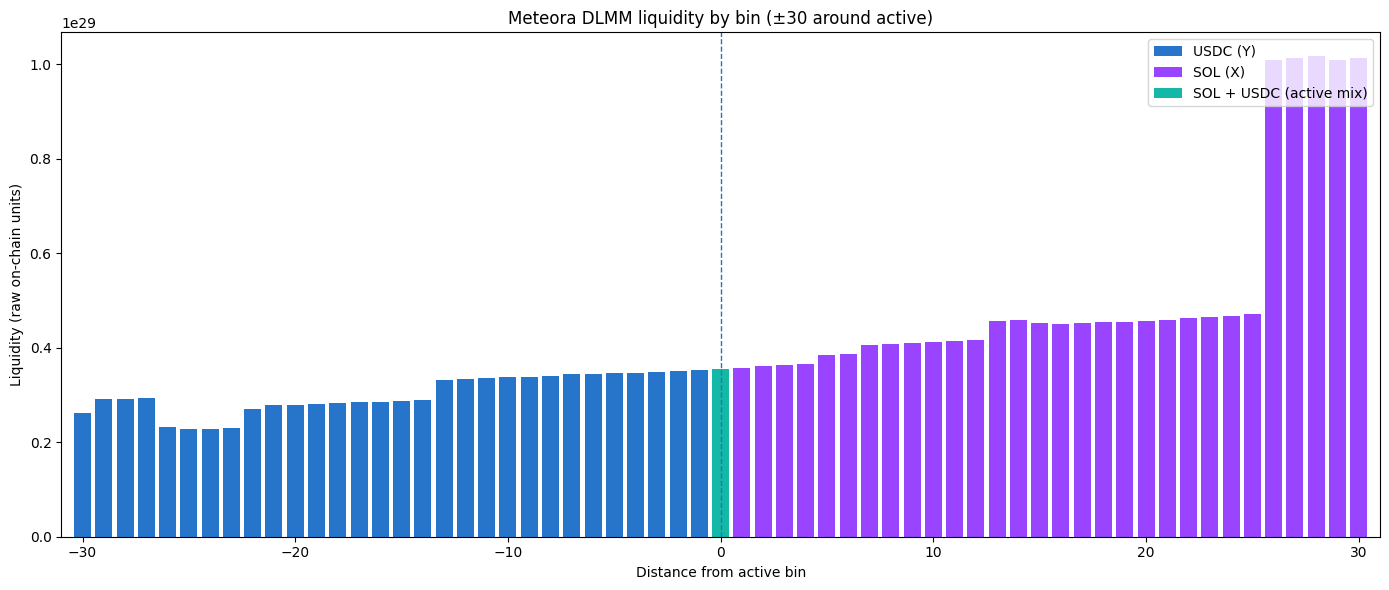

In [35]:
from matplotlib.patches import Patch

plot_df = neighborhood_df
bar_colors = plot_df.apply(
    lambda row: bar_color_for_bin(
        row["x_amount"], row["y_amount"], row["distance_from_active"]
    ),
    axis=1,
)

fig, ax = plt.subplots(figsize=(14, 6))
bar_width = 0.8
ax.bar(
    plot_df["distance_from_active"],
    plot_df["liquidity"],
    width=bar_width,
    color=bar_colors,
)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlim(-ZOOM_BINS - 1, ZOOM_BINS + 1)
ax.set_xlabel("Distance from active bin")
ax.set_ylabel("Liquidity (raw on-chain units)")
ax.set_title(f"Meteora DLMM liquidity by bin (±{ZOOM_BINS} around active)")
ax.legend(
    handles=[
        Patch(facecolor=TOKEN_COLORS["Y"], label=f"{TOKEN_Y} (Y)"),
        Patch(facecolor=TOKEN_COLORS["X"], label=f"{TOKEN_X} (X)"),
        Patch(facecolor=TOKEN_COLORS["mix"], label=f"{TOKEN_X} + {TOKEN_Y} (active mix)"),
    ],
    loc="upper right",
)
fig.tight_layout()
plt.show()

## Microstructure notes

The active bin functions as a local coordinate center. Liquidity away from the active bin is a discrete field over price bins. A single snapshot gives the static shape; repeated snapshots would show migration and deformation.

## Next questions

- How concentrated is liquidity around the active bin?
- How asymmetric is liquidity on either side?
- How does the active bin move over time?
- Do volatile pools show wider liquidity distributions?
- How do stable pools differ from memecoin or SOL pairs?